# ANOVA — Practical Notebook

This notebook accompanies the ANOVA README and focuses on one-way ANOVA, variance decomposition, F statistics, assumptions, post-hoc analysis, effect size, and interpretation.

## Learning Objectives

- calculate group and grand means;
- calculate between-, within-, and total sums of squares;
- calculate degrees of freedom and mean squares;
- calculate and interpret the F statistic;
- perform one-way ANOVA with Python;
- inspect assumptions visually;
- use post-hoc comparisons after a significant ANOVA;
- calculate eta squared.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

## 1. Example Dataset

Three independent groups contain quantitative observations.

In [2]:
A = np.array([10, 12, 14])
B = np.array([16, 18, 20])
C = np.array([22, 24, 26])

data = pd.DataFrame({
    'Group': ['A']*3 + ['B']*3 + ['C']*3,
    'Score': np.concatenate([A, B, C])
})
print(data)
print('\nGroup means:')
print(data.groupby('Group')['Score'].mean())
print('\nGrand mean:', data['Score'].mean())

  Group  Score
0     A     10
1     A     12
2     A     14
3     B     16
4     B     18
5     B     20
6     C     22
7     C     24
8     C     26

Group means:
Group
A    12.0
B    18.0
C    24.0
Name: Score, dtype: float64

Grand mean: 18.0


## 2. Manual Sum of Squares

Calculate $SS_B$, $SS_W$, and $SS_T$ directly from the observations.

In [3]:
grand_mean = data['Score'].mean()

ss_between = sum(
    len(group) * (group['Score'].mean() - grand_mean)**2
    for _, group in data.groupby('Group')
)

ss_within = sum(
    ((group['Score'] - group['Score'].mean())**2).sum()
    for _, group in data.groupby('Group')
)

ss_total = ((data['Score'] - grand_mean)**2).sum()

print('SS Between:', ss_between)
print('SS Within:', ss_within)
print('SS Total:', ss_total)
print('Check:', ss_between + ss_within)

SS Between: 216.0
SS Within: 24.0
SS Total: 240.0
Check: 240.0


## 3. Degrees of Freedom, Mean Squares, and F

In [4]:
k = data['Group'].nunique()
N = len(data)

df_between = k - 1
df_within = N - k
df_total = N - 1

ms_between = ss_between / df_between
ms_within = ss_within / df_within
F = ms_between / ms_within

print('df between:', df_between)
print('df within:', df_within)
print('df total:', df_total)
print('MS between:', ms_between)
print('MS within:', ms_within)
print('F statistic:', F)

df between: 2
df within: 6
df total: 8
MS between: 108.0
MS within: 4.0
F statistic: 27.0


## 4. One-Way ANOVA with SciPy

The library implementation can perform the same overall test.

In [5]:
result = stats.f_oneway(A, B, C)
print('F statistic:', result.statistic)
print('p-value:', result.pvalue)

F statistic: 27.0
p-value: 0.0010000000000000002


## 5. Visualise the Groups

A box plot provides a quick view of group centres, spread, and potential outliers.

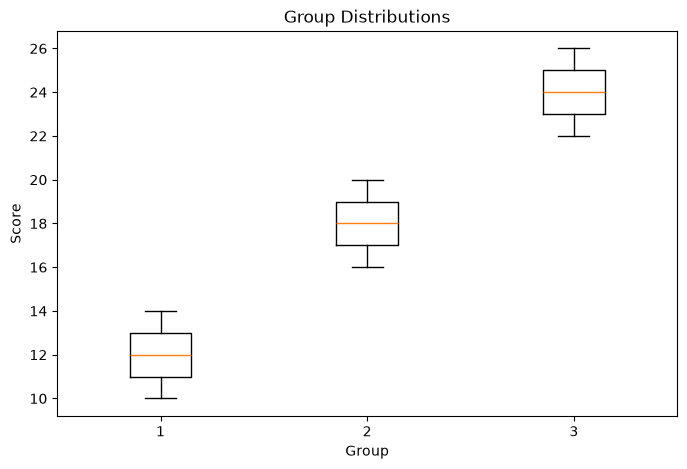

In [7]:
plt.figure(figsize=(8, 5))
plt.boxplot([A, B, C], label=['A', 'B', 'C'])
plt.xlabel('Group')
plt.ylabel('Score')
plt.title('Group Distributions')
plt.show()

## 6. A Less Separated Example

Here the group means are closer together.

In [8]:
G1 = np.array([10, 11, 12, 11, 10])
G2 = np.array([11, 12, 10, 12, 11])
G3 = np.array([12, 11, 13, 12, 11])

result = stats.f_oneway(G1, G2, G3)
print('F statistic:', result.statistic)
print('p-value:', result.pvalue)

F statistic: 1.8095238095238093
p-value: 0.20566490174749516


## 7. Post-Hoc Tukey HSD

When the overall ANOVA is significant, post-hoc comparisons can identify which pairs differ. SciPy provides Tukey's HSD in current versions.

In [9]:
from scipy.stats import tukey_hsd

tukey = tukey_hsd(A, B, C)
print(tukey)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -6.000     0.024   -11.010    -0.990
 (0 - 2)    -12.000     0.001   -17.010    -6.990
 (1 - 0)      6.000     0.024     0.990    11.010
 (1 - 2)     -6.000     0.024   -11.010    -0.990
 (2 - 0)     12.000     0.001     6.990    17.010
 (2 - 1)      6.000     0.024     0.990    11.010



## 8. Effect Size — Eta Squared

In [10]:
eta_squared = ss_between / ss_total
print('Eta squared:', eta_squared)

Eta squared: 0.9


## 9. Residuals

For one-way ANOVA, residuals are the observations minus their corresponding group means.

In [11]:
data['GroupMean'] = data.groupby('Group')['Score'].transform('mean')
data['Residual'] = data['Score'] - data['GroupMean']
print(data)

  Group  Score  GroupMean  Residual
0     A     10       12.0      -2.0
1     A     12       12.0       0.0
2     A     14       12.0       2.0
3     B     16       18.0      -2.0
4     B     18       18.0       0.0
5     B     20       18.0       2.0
6     C     22       24.0      -2.0
7     C     24       24.0       0.0
8     C     26       24.0       2.0


## 10. Residual Plot

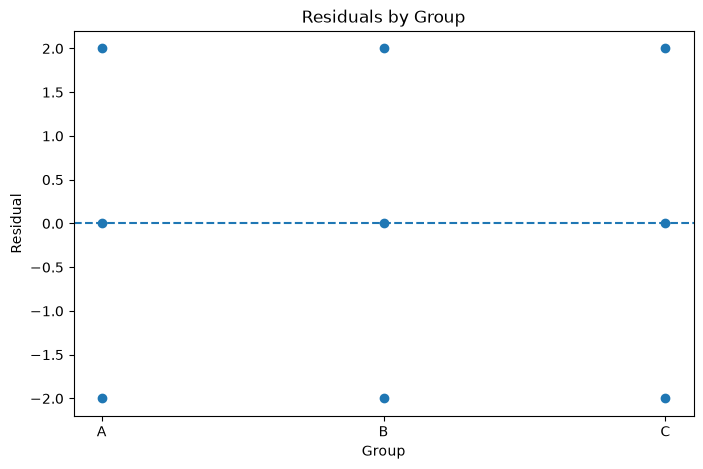

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(data['Group'], data['Residual'])
plt.axhline(0, linestyle='--')
plt.xlabel('Group')
plt.ylabel('Residual')
plt.title('Residuals by Group')
plt.show()

## 11. Variance Comparison

A simple visual comparison of group spreads can help identify possible variance differences.

In [13]:
for name, group in data.groupby('Group'):
    print(name, 'variance =', group['Score'].var(ddof=1))

A variance = 4.0
B variance = 4.0
C variance = 4.0


## 12. Levene's Test

Levene's test can be used as one diagnostic for equality of variances.

In [14]:
levene = stats.levene(A, B, C)
print('Levene statistic:', levene.statistic)
print('p-value:', levene.pvalue)

Levene statistic: 0.0
p-value: 1.0


## 13. Welch's ANOVA

When equal variances are questionable, Welch's ANOVA is an alternative. SciPy's implementation may depend on the installed version; the following uses the current API when available.

In [15]:
try:
    from scipy.stats import f_oneway
    welch_result = f_oneway(A, B, C, equal_var=False)
    print('Welch F statistic:', welch_result.statistic)
    print('Welch p-value:', welch_result.pvalue)
except TypeError:
    print('This SciPy version does not expose equal_var=False in f_oneway.')

Welch F statistic: 23.142857142857142
Welch p-value: 0.006327479338842975


## 14. Practice Questions

1. What is the purpose of one-way ANOVA?
2. Write the null and alternative hypotheses for three population means.
3. Explain the difference between within-group and between-group variation.
4. Calculate $df_B$, $df_W$, and $df_T$ when $k=4$ and $N=40$.
5. Explain why the F statistic is a ratio of mean squares.
6. What does a significant ANOVA tell us?
7. What does it not tell us?
8. Why are post-hoc comparisons used?
9. What is eta squared?
10. Name the main assumptions of classical one-way ANOVA.
11. Why can Welch's ANOVA be useful?
12. Explain why many unadjusted pairwise t-tests can be problematic.

## 15. Final Checklist

Before reporting ANOVA, verify the study design, independence, group structure, response variable, group sizes, variance behaviour, outliers, normality of residuals, ANOVA table, F statistic, p-value, effect size, and post-hoc procedure when needed.